# Прогноз цены подержанных автомобилей

Исходный файл занимает 9,3 ГиБ. Для обучения он читается потоково, а SHA-256 рассчитывается отдельным потоковым проходом для паспорта артефакта. Формируется детерминированная выборка по listing_id: правило выбора не использует цену и не создаёт утечку.

## 0. Импорты и настройки

In [1]:
from datetime import datetime, timezone
import hashlib
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
DATASET_NAME = 'used_cars_data.csv'
SAMPLE_MODULO = 12
CHUNK_SIZE = 100_000

def find_project_root(start: Path, dataset_name: str) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / dataset_name).exists():
            return candidate
    for candidate in candidates:
        if (candidate / '.git').exists():
            return candidate
    raise FileNotFoundError(f'Could not find {dataset_name} from {start.resolve()}')

PROJECT_ROOT = find_project_root(Path.cwd(), DATASET_NAME)
DATASET_PATH = PROJECT_ROOT / DATASET_NAME
ARTIFACT_PATH = PROJECT_ROOT / 'artifacts' / 'model.joblib'

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

DATASET_SHA256 = sha256_file(DATASET_PATH)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
print('Project root resolved from the current working tree.')
print(f'Dataset size: {DATASET_PATH.stat().st_size / 1024**3:.2f} GiB')

Project root resolved from the current working tree.
Dataset size: 9.29 GiB


## 1. Загрузка данных

Одна строка описывает одно объявление о продаже автомобиля. Целевая переменная price содержит заявленную стоимость машины. Поле savings_amount намеренно не используется, так как оно рассчитывается на основе цены.

In [2]:
TARGET = 'price'
FEATURES_TO_USE = [
    'make_name', 'model_name', 'year', 'mileage', 'engine_displacement',
    'horsepower', 'fuel_type', 'transmission_display', 'body_type',
    'wheel_system', 'is_new', 'has_accidents',
]
ID_COLUMNS = ['vin', 'listing_id']
POSSIBLE_LEAKAGE = ['description', 'daysonmarket', 'listed_date', 'savings_amount']
SELLER_OR_LOCATION_COLUMNS = [
    'city', 'dealer_zip', 'latitude', 'longitude', 'sp_id', 'sp_name',
    'seller_rating', 'franchise_dealer', 'franchise_make',
]

source_columns = pd.read_csv(DATASET_PATH, nrows=0).columns.tolist()
required_columns = [TARGET, *FEATURES_TO_USE, *ID_COLUMNS]
missing_required = sorted(set(required_columns) - set(source_columns))
if missing_required:
    raise ValueError(f'Missing source columns: {missing_required}')

def load_deterministic_sample(path: Path) -> tuple[pd.DataFrame, int]:
    selected_columns = list(dict.fromkeys([TARGET, *FEATURES_TO_USE, *ID_COLUMNS]))
    parts, source_rows = [], 0
    for chunk in pd.read_csv(path, usecols=selected_columns, chunksize=CHUNK_SIZE):
        source_rows += len(chunk)
        listing_ids = pd.to_numeric(chunk['listing_id'], errors='coerce').astype('Int64')
        mask = listing_ids.notna() & (listing_ids % SAMPLE_MODULO == 0)
        parts.append(chunk.loc[mask].copy())
    return pd.concat(parts, ignore_index=True), source_rows

raw_df, source_rows = load_deterministic_sample(DATASET_PATH)
print(f'Full source rows scanned: {source_rows:,}')
print(f'Deterministic modeling sample shape: {raw_df.shape}')
display(raw_df.head())
print('Source columns:', source_columns)
display(raw_df.dtypes.to_frame('dtype'))
print(f'Target column: {TARGET}')
print(f'Exact duplicates in sample: {raw_df.duplicated().sum():,}')

Full source rows scanned: 3,000,040
Deterministic modeling sample shape: (250034, 15)


,vin,body_type,engine_displacement,fuel_type,has_accidents,horsepower,is_new,listing_id,make_name,mileage,model_name,price,transmission_display,wheel_system,year
0,SALRG2RK9L2433143,SUV / Crossover,"3,000.00",Diesel,NaN,254.00,True,266911044,Land Rover,13.00,Discovery,"68,950.00",8-Speed Automatic Overdrive,AWD,2020
1,1GNERFKW0JJ104068,SUV / Crossover,"3,600.00",Gasoline,False,310.00,False,279129180,Chevrolet,"36,410.00",Traverse,"23,723.00",9-Speed Automatic,FWD,2018
2,JM3KFABM0K1521253,SUV / Crossover,"2,500.00",Gasoline,NaN,187.00,True,236399040,Mazda,16.00,CX-5,"28,345.00",6-Speed Automatic Overdrive,FWD,2019
3,ZACNJBC11KPK05419,SUV / Crossover,"1,300.00",Gasoline,NaN,177.00,True,238649856,Jeep,20.00,Renegade,"31,221.00",9-Speed Automatic Overdrive,4WD,2019
4,1C4RDJDG2JC150071,SUV / Crossover,"3,600.00",Gasoline,True,295.00,False,277801764,Dodge,"15,732.00",Durango,"27,300.00",8-Speed Automatic,AWD,2018


Source columns: ['vin', 'back_legroom', 'bed', 'bed_height', 'bed_length', 'body_type', 'cabin', 'city', 'city_fuel_economy', 'combine_fuel_economy', 'daysonmarket', 'dealer_zip', 'description', 'engine_cylinders', 'engine_displacement', 'engine_type', 'exterior_color', 'fleet', 'frame_damaged', 'franchise_dealer', 'franchise_make', 'front_legroom', 'fuel_tank_volume', 'fuel_type', 'has_accidents', 'height', 'highway_fuel_economy', 'horsepower', 'interior_color', 'isCab', 'is_certified', 'is_cpo', 'is_new', 'is_oemcpo', 'latitude', 'length', 'listed_date', 'listing_color', 'listing_id', 'longitude', 'main_picture_url', 'major_options', 'make_name', 'maximum_seating', 'mileage', 'model_name', 'owner_count', 'power', 'price', 'salvage', 'savings_amount', 'seller_rating', 'sp_id', 'sp_name', 'theft_title', 'torque', 'transmission', 'transmission_display', 'trimId', 'trim_name', 'vehicle_damage_category', 'wheel_system', 'wheel_system_display', 'wheelbase', 'width', 'year']


,dtype
vin,object
body_type,object
engine_displacement,float64
fuel_type,object
has_accidents,object
horsepower,float64
is_new,bool
listing_id,int64
make_name,object
mileage,float64


Target column: price
Exact duplicates in sample: 2


## 2. Первичный аудит данных

Аудит относится к детерминированной выборке для моделирования и выбранным входным полям. Полный список колонок исходного файла напечатан выше.

,dtype,missing_count,missing_share,n_unique
has_accidents,object,118825,0.48,2
engine_displacement,float64,14432,0.06,65
horsepower,float64,14432,0.06,419
wheel_system,object,12214,0.05,5
mileage,float64,12103,0.05,79804
fuel_type,object,6825,0.03,7
transmission_display,object,5385,0.02,37
body_type,object,1084,0.00,9
vin,object,0,0.00,250032
is_new,bool,0,0.00,2


,price
0.00,165.00
0.01,"4,499.00"
0.25,"18,450.00"
0.50,"26,428.00"
0.75,"38,130.00"
0.99,"84,354.34"
1.00,"2,749,950.00"


price min=165, median=26,428, mean=29,923, max=2,749,950


,count,mean,std,min,25%,50%,75%,max
engine_displacement,"235,602.00","2,967.20","1,346.25",700.00,"2,000.00","2,500.00","3,600.00","8,400.00"
horsepower,"235,602.00",247.94,90.43,67.00,175.00,244.00,300.00,949.00
listing_id,"250,034.00","275,499,352.79","8,885,015.26","59,993,232.00","274,570,578.00","278,540,934.00","280,452,081.00","282,019,140.00"
mileage,"237,931.00","31,106.69","45,317.37",0.00,6.00,"8,308.00","43,633.50","514,033.00"
price,"250,034.00","29,923.47","19,956.70",165.00,"18,450.00","26,428.00","38,130.00","2,749,950.00"
year,"250,034.00","2,017.72",4.21,"1,923.00","2,017.00","2,020.00","2,020.00","2,021.00"


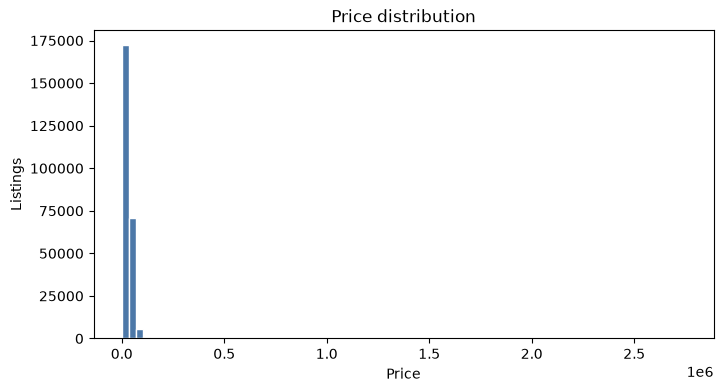

In [3]:
audit = pd.DataFrame({
    'dtype': raw_df.dtypes.astype(str),
    'missing_count': raw_df.isna().sum(),
    'missing_share': raw_df.isna().mean(),
    'n_unique': raw_df.nunique(dropna=True),
}).sort_values('missing_share', ascending=False)
display(audit)
display(raw_df[TARGET].quantile([0, .01, .25, .5, .75, .99, 1]).rename('price').to_frame())
print(f'price min={raw_df[TARGET].min():,.0f}, median={raw_df[TARGET].median():,.0f}, mean={raw_df[TARGET].mean():,.0f}, max={raw_df[TARGET].max():,.0f}')
display(raw_df.select_dtypes(include='number').describe().T)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(raw_df[TARGET].dropna(), bins=80, color='#4C78A8', edgecolor='white')
ax.set(title='Price distribution', xlabel='Price', ylabel='Listings')
plt.show()

## 3. Утечки и неподходящие колонки

vin и listing_id являются идентификаторами. В description может встречаться информация о цене. daysonmarket становится известен только после публикации объявления. listed_date может дать модели временную подсказку. savings_amount зависит от цены. Данные о продавце и местоположении исключены, потому что первая версия оценивает автомобиль, а не дилера или рынок. Остальные поля не берутся в базовую модель, чтобы она оставалась небольшой и понятной.

In [4]:
COLUMN_CLASSIFICATION = {
    'TARGET': [TARGET],
    'FEATURE': FEATURES_TO_USE,
    'ID': ID_COLUMNS,
    'POSSIBLE_LEAKAGE': POSSIBLE_LEAKAGE,
}
classified_columns = {column for columns in COLUMN_CLASSIFICATION.values() for column in columns}
COLUMN_CLASSIFICATION['DROP'] = sorted(set(source_columns) - classified_columns)
assert set(source_columns) == {column for columns in COLUMN_CLASSIFICATION.values() for column in columns}
classification_table = pd.DataFrame(
    [(column, label) for label, columns in COLUMN_CLASSIFICATION.items() for column in columns],
    columns=['column', 'classification'],
).sort_values(['classification', 'column']).reset_index(drop=True)
display(classification_table)
print('POSSIBLE_LEAKAGE explanation: price-adjacent, post-listing, or free-text fields.')
print('DROP explanation: seller, location, image, trim, and out-of-scope vehicle fields for this baseline.')
cardinality = raw_df[FEATURES_TO_USE].nunique(dropna=True).sort_values(ascending=False)
display(cardinality.rename('n_unique').to_frame())

,column,classification
0,back_legroom,DROP
1,bed,DROP
2,bed_height,DROP
3,bed_length,DROP
4,cabin,DROP
...,...,...
61,daysonmarket,POSSIBLE_LEAKAGE
62,description,POSSIBLE_LEAKAGE
63,listed_date,POSSIBLE_LEAKAGE
64,savings_amount,POSSIBLE_LEAKAGE


POSSIBLE_LEAKAGE explanation: price-adjacent, post-listing, or free-text fields.
DROP explanation: seller, location, image, trim, and out-of-scope vehicle fields for this baseline.


,n_unique
mileage,79804
model_name,1037
horsepower,419
year,86
make_name,68
engine_displacement,65
transmission_display,37
body_type,9
fuel_type,7
wheel_system,5


У model_name ожидается самая высокая кардинальность. Фактическое число уникальных значений показано выше. Для этой выборки one-hot кодирование остаётся приемлемым. Незнакомые модели при предсказании будут обработаны безопасно. Если число категорий станет слишком большим, в следующей версии лучше использовать модель с нативной поддержкой категориальных признаков, а не добавлять target encoding.

## 4. Базовая очистка

Очистка оформлена отдельной фиксированной функцией и не зависит от разбиения на выборки. Она удаляет полные дубликаты, неположительную цену, отрицательный пробег и годы вне возможного диапазона. Экстремальные значения показаны отдельно. Автоматическое удаление выбросов по правилу IQR не применяется.

In [5]:
MIN_VALID_YEAR = 1886
MAX_VALID_YEAR = 2021  # Maximum observed model year in this fixed 2020 dataset snapshot.
display(raw_df['mileage'].quantile([0, .01, .5, .99, 1]).rename('mileage').to_frame())
display(raw_df['year'].quantile([0, .01, .5, .99, 1]).rename('year').to_frame())
print('Prices above 99th percentile:', (raw_df[TARGET] > raw_df[TARGET].quantile(.99)).sum())

def clean_data(frame: pd.DataFrame) -> pd.DataFrame:
    cleaned = frame.drop_duplicates().copy()
    cleaned = cleaned.loc[cleaned[TARGET].gt(0)]
    cleaned = cleaned.loc[cleaned['mileage'].isna() | cleaned['mileage'].ge(0)]
    cleaned = cleaned.loc[cleaned['year'].isna() | cleaned['year'].between(MIN_VALID_YEAR, MAX_VALID_YEAR)]
    return cleaned.reset_index(drop=True)

df = clean_data(raw_df)
duplicate_vin_rows = int(df['vin'].duplicated(keep=False).sum())
assert duplicate_vin_rows == 0, 'The same VIN must not cross train/validation/test splits.'
print(f'Rows before cleaning: {len(raw_df):,}')
print(f'Rows after cleaning: {len(df):,}')
print(f'Rows removed: {len(raw_df) - len(df):,}')
print(f'Duplicate VIN rows after cleaning: {duplicate_vin_rows:,}')

,mileage
0.00,0.00
0.01,0.00
0.50,"8,308.00"
0.99,"188,500.70"
1.00,"514,033.00"


,year
0.00,"1,923.00"
0.01,"2,003.00"
0.50,"2,020.00"
0.99,"2,021.00"
1.00,"2,021.00"


Prices above 99th percentile: 2501


Rows before cleaning: 250,034
Rows after cleaning: 250,032
Rows removed: 2
Duplicate VIN rows after cleaning: 0


## 5. Разбиение на train validation и test

Используется случайное разбиение 70 процентов для train и по 15 процентов для validation и test. В наборе есть listed_date, но это поле исключено из первой версии. Временное разбиение стоит добавить позже, когда будет определён период работы будущего сервиса.

In [6]:
X, y = df[FEATURES_TO_USE].copy(), df[TARGET].copy()
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=.15, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=.15/.85, random_state=RANDOM_STATE)
for name, features, target in [('train', X_train, y_train), ('validation', X_val, y_val), ('test', X_test, y_test)]:
    print(f'{name:10s}: X={features.shape}, y={target.shape}')
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = [column for column in FEATURES_TO_USE if column not in numeric_features]
print('numeric_features:', numeric_features)
print('categorical_features:', categorical_features)

train     : X=(175022, 12), y=(175022,)
validation: X=(37505, 12), y=(37505,)
test      : X=(37505, 12), y=(37505,)
numeric_features: ['year', 'mileage', 'engine_displacement', 'horsepower']
categorical_features: ['make_name', 'model_name', 'fuel_type', 'transmission_display', 'body_type', 'wheel_system', 'is_new', 'has_accidents']


## 6. Типы признаков

После разбиения признаки делятся на числовые и категориальные. Целевая переменная в эти списки не входит.

## 7. Конвейер предобработки

В финальный конвейер входят все преобразования и сама модель. Благодаря этому один и тот же артефакт можно применять во время обучения и позднее в FastAPI без расхождения между обучением и сервисом.

## 8. Наивная модель

Предсказатель медианной цены помогает понять, даёт ли обученная модель полезный прирост качества.

## 9. Базовая модель на линейной регрессии

Обе модели обучаются только на train. Validation используется для сравнения моделей и анализа ошибок.

In [7]:
def make_preprocessor() -> ColumnTransformer:
    numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
    return ColumnTransformer([
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features),
    ])

def regression_metrics(y_true, y_pred) -> dict:
    return {'mae': float(mean_absolute_error(y_true, y_pred)), 'rmse': float(root_mean_squared_error(y_true, y_pred)), 'r2': float(r2_score(y_true, y_pred))}

linear_pipeline = Pipeline([('preprocessor', make_preprocessor()), ('model', LinearRegression())])

dummy_pipeline = Pipeline([('preprocessor', make_preprocessor()), ('model', DummyRegressor(strategy='median'))])
dummy_pipeline.fit(X_train, y_train)
dummy_validation_metrics = regression_metrics(y_val, dummy_pipeline.predict(X_val))
display(pd.Series(dummy_validation_metrics, name='DummyRegressor validation'))

linear_pipeline.fit(X_train, y_train)
val_pred = linear_pipeline.predict(X_val)
linear_validation_metrics = regression_metrics(y_val, val_pred)
display(pd.Series(linear_validation_metrics, name='LinearRegression validation'))

mae    12,385.41
rmse   18,307.54
r2         -0.04
Name: DummyRegressor validation, dtype: float64

mae    4,394.36
rmse   7,583.67
r2         0.82
Name: LinearRegression validation, dtype: float64

## 10. Анализ ошибок

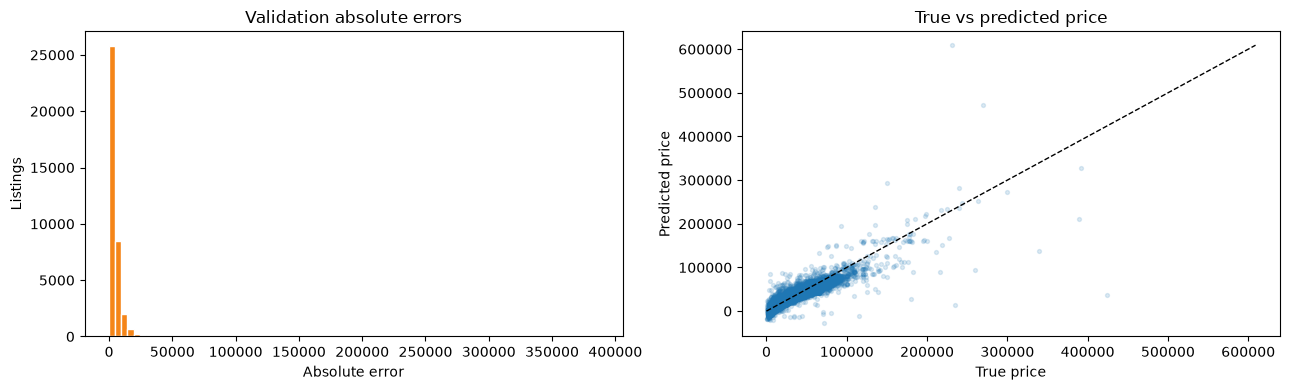

,make_name,model_name,year,mileage,engine_displacement,horsepower,fuel_type,transmission_display,body_type,wheel_system,is_new,has_accidents,y_true,y_pred,absolute_error,relative_error
32328,GMC,Acadia,2021,5.00,NaN,NaN,NaN,9-Speed Automatic,SUV / Crossover,NaN,True,NaN,"424,060.00","37,636.69","386,423.31",0.91
22536,Ferrari,F12 Berlinetta,2016,"8,587.00","6,300.00",731.00,Gasoline,7-Speed Dual Clutch,Coupe,RWD,False,False,"230,900.00","609,111.79","378,211.79",1.64
10088,Chevrolet,Corvette,1963,103.00,NaN,NaN,Gasoline,5-Speed Automatic,Coupe,NaN,False,False,"234,900.00","14,817.07","220,082.93",0.94
22000,Porsche,911,2019,"1,644.00","3,800.00",700.00,Gasoline,Automatic,Coupe,RWD,False,False,"338,995.00","136,662.19","202,332.81",0.60
26384,Lamborghini,Aventador,2013,"9,767.00","6,500.00",691.00,Gasoline,7-Speed Automatic,Coupe,AWD,False,True,"269,800.00","471,913.01","202,113.01",0.75
8901,Rolls-Royce,Ghost,2020,35.00,"6,600.00",563.00,Gasoline,Automatic,Sedan,RWD,True,NaN,"389,675.00","210,143.90","179,531.10",0.46
32800,Porsche,911,2011,"4,997.00",NaN,NaN,NaN,7-Speed Automatic,Coupe,NaN,False,False,"259,999.00","94,808.60","165,190.40",0.64
14195,Plymouth,Belvedere,1966,"32,543.00",NaN,NaN,NaN,Automatic,Sedan,NaN,False,False,"179,950.00","27,833.59","152,116.41",0.85
16590,Ferrari,550,2001,"17,314.00","5,500.00",485.00,Gasoline,5-Speed Manual,Coupe,RWD,False,True,"149,999.00","294,486.22","144,487.22",0.96
32434,Land Rover,Range Rover,2020,1.00,"5,000.00",557.00,Gasoline,Automatic,SUV / Crossover,AWD,True,NaN,"216,314.00","88,574.89","127,739.11",0.59


,rows,mae
make_name,,
Maserati,33,"19,111.04"
Porsche,166,"19,075.76"
Land Rover,201,"10,554.76"
Mercedes-Benz,875,"8,960.50"
BMW,751,"8,580.26"
Pontiac,34,"8,431.06"
Jaguar,110,"8,233.38"
Audi,463,"6,734.16"
RAM,1239,"6,121.24"


,rows,mae
year_bucket,,
"[1885, 2000)",137,"20,699.37"
"[2000, 2010)",1644,"6,462.42"
"[2010, 2015)",3425,"4,813.42"
"[2015, 2020)",13187,"3,645.20"
"[2020, 2030)",19112,"4,541.40"


- Большие ошибки ожидаемы у редких и дорогих комплектаций.
- Зависимость цены от пробега, года, комплектации и мощности нелинейна.
- Следующей модели пригодятся нелинейный алгоритм, более полные признаки состояния и временная оценка качества.

In [8]:
validation_results = X_val.reset_index(drop=True).copy()
validation_results['y_true'] = y_val.reset_index(drop=True)
validation_results['y_pred'] = val_pred
validation_results['absolute_error'] = (validation_results['y_true'] - validation_results['y_pred']).abs()
validation_results['relative_error'] = validation_results['absolute_error'] / validation_results['y_true']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(validation_results['absolute_error'], bins=80, color='#F58518', edgecolor='white')
axes[0].set(title='Validation absolute errors', xlabel='Absolute error', ylabel='Listings')
axes[1].scatter(validation_results['y_true'], validation_results['y_pred'], alpha=.15, s=8)
limit = max(validation_results['y_true'].max(), validation_results['y_pred'].max())
axes[1].plot([0, limit], [0, limit], '--', color='black', linewidth=1)
axes[1].set(title='True vs predicted price', xlabel='True price', ylabel='Predicted price')
plt.tight_layout(); plt.show()
display(validation_results.sort_values('absolute_error', ascending=False).head(10))
mae_by_make = validation_results.groupby('make_name').agg(rows=('absolute_error', 'size'), mae=('absolute_error', 'mean')).query('rows >= 30').sort_values('mae', ascending=False).head(10)
validation_results['year_bucket'] = pd.cut(validation_results['year'], [1885, 2000, 2010, 2015, 2020, 2030], right=False)
mae_by_year = validation_results.groupby('year_bucket', observed=False)['absolute_error'].agg(rows='size', mae='mean')
display(mae_by_make); display(mae_by_year)
display(Markdown('- Большие ошибки ожидаемы у редких и дорогих комплектаций.\n- Зависимость цены от пробега, года, комплектации и мощности нелинейна.\n- Следующей модели пригодятся нелинейный алгоритм, более полные признаки состояния и временная оценка качества.'))

## 11. Финальная оценка

Выше test не использовался. Теперь один финальный pipeline обучается на train вместе с validation и один раз оценивается на test.

## 12. Артефакт модели

In [9]:
final_pipeline = clone(linear_pipeline)
final_pipeline.fit(X_train_val, y_train_val)
test_metrics = regression_metrics(y_test, final_pipeline.predict(X_test))
display(pd.Series(test_metrics, name='LinearRegression test'))
ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
bundle = {
    'pipeline': final_pipeline,
    'metadata': {
        'model_version': '0.1.0', 'model_type': 'sklearn.linear_model.LinearRegression',
        'target': TARGET, 'input_features': FEATURES_TO_USE,
        'numeric_features': numeric_features, 'categorical_features': categorical_features,
        'metrics_test': test_metrics, 'random_state': RANDOM_STATE,
        'training_rows': int(len(X_train_val)), 'dataset_filename': DATASET_PATH.name,
        'dataset_size_bytes': int(DATASET_PATH.stat().st_size),
        'sampling_rule': f'listing_id % {SAMPLE_MODULO} == 0',
        'source_rows_scanned': int(source_rows),
        'dataset_hash_algorithm': 'sha256', 'dataset_hash': DATASET_SHA256,
        'created_at_utc': datetime.now(timezone.utc).isoformat(),
    },
}
joblib.dump(bundle, ARTIFACT_PATH)
loaded_bundle = joblib.load(ARTIFACT_PATH)
smoke_test_prediction = loaded_bundle['pipeline'].predict(X_test.iloc[[0]])
print(f'Saved: {ARTIFACT_PATH.relative_to(PROJECT_ROOT)}')
print(f'Smoke-test prediction: {smoke_test_prediction[0]:,.2f}')

mae     4,474.56
rmse   11,206.43
r2          0.70
Name: LinearRegression test, dtype: float64

Saved: artifacts/model.joblib
Smoke-test prediction: 23,661.07


## 13. Пример запроса для предсказания

In [10]:
def to_json_value(value):
    if pd.isna(value): return None
    return value.item() if isinstance(value, np.generic) else value

example_request = {feature: to_json_value(X_test.iloc[0][feature]) for feature in FEATURES_TO_USE}
example_request = json.loads(json.dumps(example_request))
example_prediction = loaded_bundle['pipeline'].predict(pd.DataFrame([example_request], columns=FEATURES_TO_USE))[0]
print('example_request ='); display(example_request)
print(f'Prediction: {example_prediction:,.2f}')

example_request =


{'make_name': 'Nissan',
 'model_name': 'Sentra',
 'year': 2020,
 'mileage': 5.0,
 'engine_displacement': 2000.0,
 'horsepower': 149.0,
 'fuel_type': 'Gasoline',
 'transmission_display': 'Continuously Variable Transmission',
 'body_type': 'Sedan',
 'wheel_system': 'FWD',
 'is_new': True,
 'has_accidents': None}

Prediction: 23,190.38


## 14. Выводы

In [11]:
display(Markdown(f'''\n- Просмотрено строк исходного файла **{source_rows:,}**. В выборке **{len(raw_df):,}** строк. После очистки осталось **{len(df):,}** строк.\n- Целевая переменная **{TARGET}**. В модели используется {len(FEATURES_TO_USE)} характеристик автомобиля.\n- MAE наивной модели на validation равна **{dummy_validation_metrics['mae']:,.0f}**.\n- Линейная регрессия на validation показывает MAE **{linear_validation_metrics['mae']:,.0f}**, RMSE **{linear_validation_metrics['rmse']:,.0f}** и R2 **{linear_validation_metrics['r2']:.3f}**.\n- Линейная регрессия на test показывает MAE **{test_metrics['mae']:,.0f}**, RMSE **{test_metrics['rmse']:,.0f}** и R2 **{test_metrics['r2']:.3f}**.\n- Исключены идентификаторы, сведения о продавце и местоположении, свободный текст, а также поля рядом с ценой или появляющиеся после публикации.\n- Ограничения модели включают выборку вместо полного набора, линейные зависимости, мало признаков состояния, отсутствие временного разбиения и комплектации.\n- Следующим шагом стоит сравнить эту модель с нелинейной моделью для категориальных признаков на тех же выборках.\n'''))


- Просмотрено строк исходного файла **3,000,040**. В выборке **250,034** строк. После очистки осталось **250,032** строк.
- Целевая переменная **price**. В модели используется 12 характеристик автомобиля.
- MAE наивной модели на validation равна **12,385**.
- Линейная регрессия на validation показывает MAE **4,394**, RMSE **7,584** и R2 **0.822**.
- Линейная регрессия на test показывает MAE **4,475**, RMSE **11,206** и R2 **0.699**.
- Исключены идентификаторы, сведения о продавце и местоположении, свободный текст, а также поля рядом с ценой или появляющиеся после публикации.
- Ограничения модели включают выборку вместо полного набора, линейные зависимости, мало признаков состояния, отсутствие временного разбиения и комплектации.
- Следующим шагом стоит сравнить эту модель с нелинейной моделью для категориальных признаков на тех же выборках.
